In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [62]:
df = pd.read_csv(
    "../data/processed/sessions_clean.csv",
    dtype={"fullVisitorId": str}
)

### Initial Discovery of the Dataset

In [63]:
df.head()

,fullVisitorId,visitId,date,country,device,channelGrouping,day_of_week,month,is_returning,pageview_bucket,revenue,transactions,visits,pageviews,converted
0,4823595352351,1478011510,2016-11-01,China,desktop,Organic Search,Tuesday,2016-11,False,"(0, 1]",0.0,0.0,1,1,False
1,10278554503158,1477029466,2016-10-20,New Zealand,desktop,Organic Search,Thursday,2016-10,False,"(5, 10]",0.0,0.0,1,8,False
2,20424342248747,1480578901,2016-11-30,Peru,desktop,Organic Search,Wednesday,2016-11,False,"(10, 20]",0.0,0.0,1,13,False
3,26722803385797,1496658394,2017-06-05,United Kingdom,desktop,Organic Search,Monday,2017-06,False,"(1, 5]",0.0,0.0,1,2,False
4,27376579751715,1486866293,2017-02-11,United States,desktop,Organic Search,Saturday,2017-02,False,"(1, 5]",0.0,0.0,1,5,False


In [64]:
df.shape

(901288, 15)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 901288 entries, 0 to 901287
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   fullVisitorId    901288 non-null  object 
 1   visitId          901288 non-null  int64  
 2   date             901288 non-null  object 
 3   country          901288 non-null  object 
 4   device           901288 non-null  object 
 5   channelGrouping  901288 non-null  object 
 6   day_of_week      901288 non-null  object 
 7   month            901288 non-null  object 
 8   is_returning     901288 non-null  bool   
 9   pageview_bucket  901191 non-null  object 
 10  revenue          901288 non-null  float64
 11  transactions     901288 non-null  float64
 12  visits           901288 non-null  int64  
 13  pageviews        901288 non-null  int64  
 14  converted        901288 non-null  bool   
dtypes: bool(2), float64(2), int64(3), object(8)
memory usage: 91.1+ MB


In [66]:
df.describe()

,visitId,revenue,transactions,visits,pageviews
count,9.012880e+05,901288.000000,901288.000000,901288.0,901288.000000
mean,1.485010e+09,1.974045,0.013434,1.0,3.855086
std,9.020338e+06,83.262875,0.128712,0.0,7.042566
min,1.470035e+09,0.000000,0.000000,1.0,0.000000
25%,1.477567e+09,0.000000,0.000000,1.0,1.000000
50%,1.483952e+09,0.000000,0.000000,1.0,1.000000
75%,1.492759e+09,0.000000,0.000000,1.0,4.000000
max,1.501657e+09,47082.060000,25.000000,1.0,469.000000


In [67]:
df['country'].unique()

array(['China', 'New Zealand', 'Peru', 'United Kingdom', 'United States',
       'Brazil', 'France', 'Pakistan', 'Japan', 'Australia', 'Russia',
       'Philippines', 'Belgium', 'Vietnam', 'Ireland', 'Turkey', 'Canada',
       'Thailand', 'India', 'Colombia', 'Taiwan', 'Morocco', 'Romania',
       'Singapore', 'South Africa', 'Malaysia', 'Czechia', 'Nigeria',
       'Sudan', 'Netherlands', 'Saudi Arabia', 'Italy', 'Germany',
       'Denmark', 'United Arab Emirates', 'Uzbekistan', 'Venezuela',
       'Hungary', 'Switzerland', 'Mexico', 'Poland', 'Argentina', 'Spain',
       'Ukraine', 'Kenya', 'Bulgaria', 'Sweden', 'Austria', 'Panama',
       'Belarus', 'South Korea', 'Guatemala', 'Greece', 'Tanzania',
       'Algeria', 'Sri Lanka', 'Indonesia', 'Bangladesh', 'Kuwait',
       'Finland', 'Israel', 'Portugal', 'Norway', 'Bosnia & Herzegovina',
       'Costa Rica', 'Ecuador', 'Congo - Kinshasa', 'Slovakia', 'Tunisia',
       'Serbia', 'Brunei', 'Bolivia', 'Egypt', 'Trinidad & Tobago',
    

In [68]:
df["country"].nunique()

221

In [69]:
df['country'].value_counts().head(15)

country
United States     364401
India              51050
United Kingdom     37378
Canada             25850
Vietnam            24592
Turkey             20515
Thailand           20104
Germany            19962
Brazil             19778
Japan              19670
France             15823
Mexico             13220
Taiwan             12950
Australia          12686
Russia             11655
Name: count, dtype: int64

In [70]:
"United States" in df['country'].values

True

In [71]:
"USA" in df['country'].values

False

In [72]:
df["channelGrouping"].value_counts()

channelGrouping
Organic Search    380537
Social            225567
Direct            142540
Referral          104653
Paid Search        25271
Affiliates         16341
Display             6259
(Other)              120
Name: count, dtype: int64

In [73]:
df = df[df['country'] != '(not set)']  #dropped country listed as "not set"

In [74]:
df['device'].value_counts()

device
desktop    662759
mobile     208153
tablet      30376
Name: count, dtype: int64

### Data Cleaning
- Check for duplicates
- Handle missing values
- Convert data types

In [75]:
df.isnull().sum().sort_values(ascending=False)

pageview_bucket    97
visitId             0
fullVisitorId       0
country             0
device              0
channelGrouping     0
date                0
day_of_week         0
month               0
is_returning        0
revenue             0
transactions        0
visits              0
pageviews           0
converted           0
dtype: int64

In [76]:
print(df.duplicated().sum())

0


In [77]:
df['transactions'] = df['transactions'].fillna(0)
df['revenue'] = df['revenue'].fillna(0)

Missing values are replaced with 0, as these variables represent numerical metrics 
(e.g., transactions and revenue), where null values likely indicate absence of activity rather than missing data.

In [78]:
df['date'] = pd.to_datetime(df['date'])

In [79]:
df['pageviews'] = df['pageviews'].fillna(0).astype(int)

### EDA

### Sessions Over Time - Key Insights

- The data shows a clear weekly seasonality pattern, indicating recurring fluctuations in user activity.
- There is a strong increase in sessions during November and December, likely driven by major shopping events such as Black Friday and the Christmas season.
- A sharp decline is observed in January, suggesting a post-holiday drop in user engagement.
- Occasional spikes may indicate marketing campaigns or special promotions.

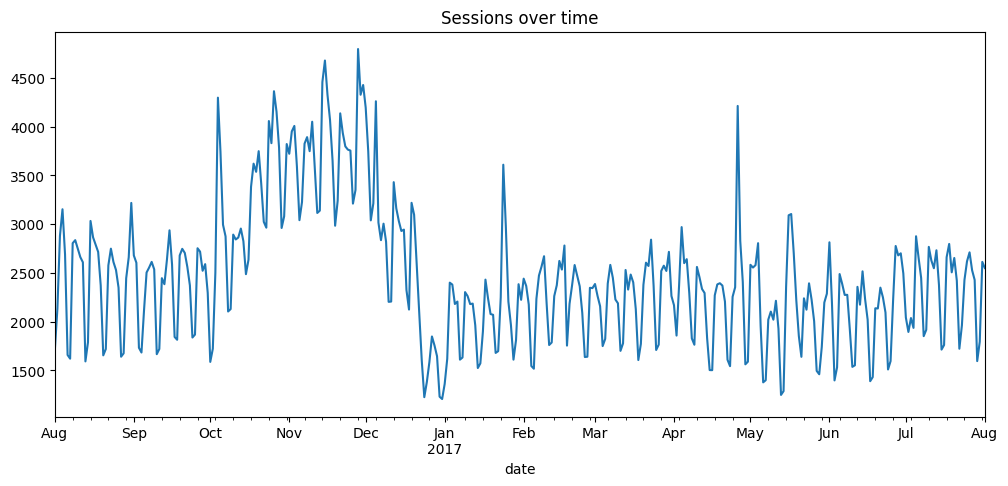

In [80]:
df.groupby('date').size().plot(figsize=(12,5))
plt.title("Sessions over time")
plt.show()

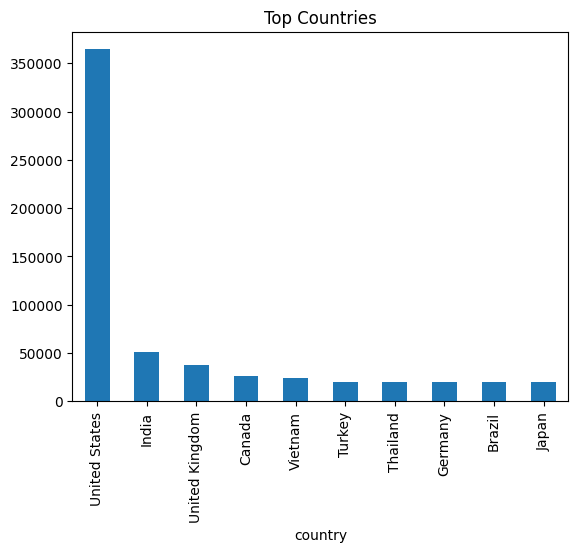

In [81]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries")
plt.show()

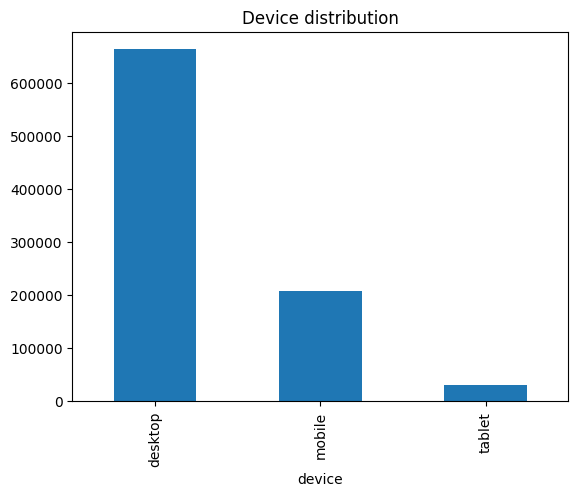

In [82]:
df['device'].value_counts().plot(kind='bar')
plt.title("Device distribution")
plt.show()

### Correlation Analysis - Key Insights

- Pageviews show a moderate positive correlation with transactions (~0.42), indicating that higher engagement increases the likelihood of conversion.
- Transactions and revenue are positively correlated (~0.24), but the relationship is not strong, suggesting variability in purchase value.
- Pageviews have a weak correlation with revenue (~0.13), meaning that browsing behavior does not directly translate into higher spending.
- Identifiers such as visitId and visitNumber do not provide meaningful analytical insights.

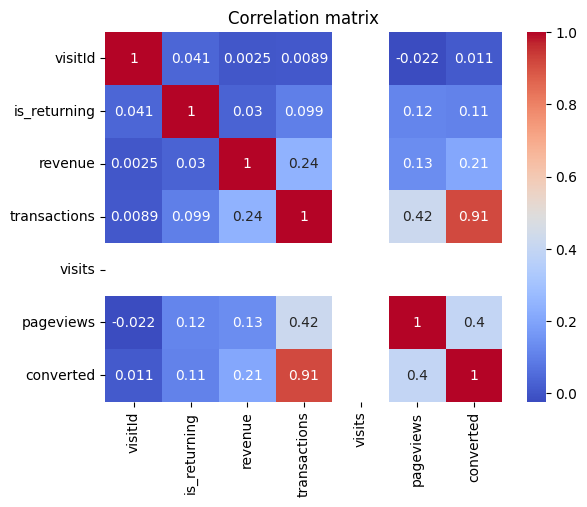

In [83]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

### Sessions by Day of Week - Key Insights

- User activity is significantly lower during weekends (Saturday and Sunday).
- Sessions peak during weekdays, especially from Tuesday to Thursday.
- This suggests that users are more engaged during working days.
- Friday shows a slight decline, indicating a transition into weekend behavior.

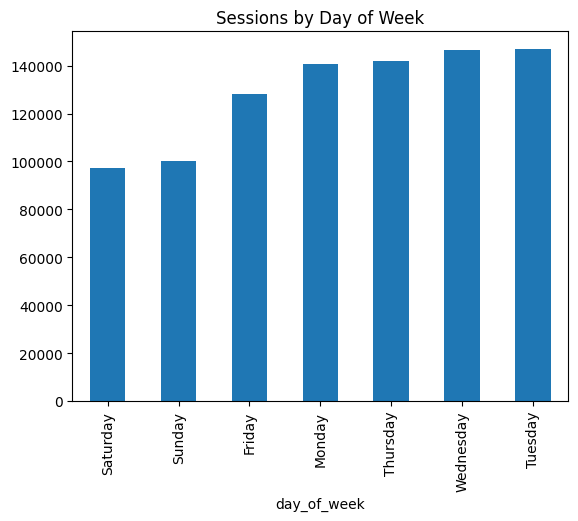

In [84]:
df['day_of_week'] = df['date'].dt.day_name()

df.groupby('day_of_week').size().sort_values().plot(kind='bar')
plt.title("Sessions by Day of Week")
plt.show()

### Revenue by Day of Week - Key Insights

- Revenue is significantly lower during weekends, despite user activity still being present.
- Mid-week days (Tuesday to Thursday) show the highest average revenue.
- This indicates that users not only visit more during weekdays but also have a higher purchase intent.
- The discrepancy between sessions and revenue suggests behavioral differences across the week.

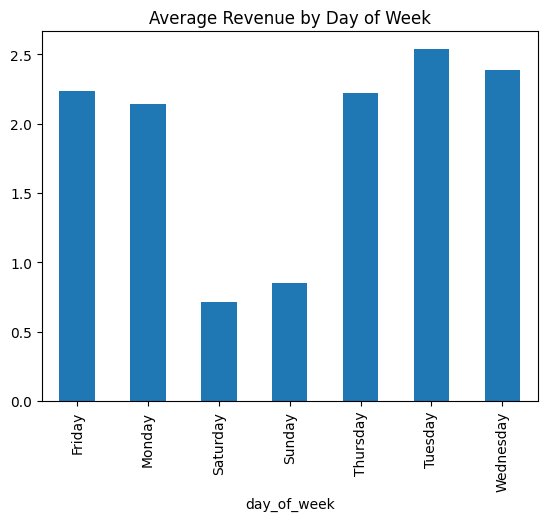

In [85]:
df.groupby('day_of_week')['revenue'].mean().plot(kind='bar')
plt.title("Average Revenue by Day of Week")
plt.show()

### Sessions by Day and Device - Key Insights

- Desktop is the dominant device across all days of the week.
- Mobile contributes a significant portion of traffic but remains secondary to desktop.
- All devices follow the same weekly pattern, with lower activity during weekends.
- The consistent drop across devices suggests a behavioral trend rather than device-specific limitations.
- Desktop users likely have higher purchase intent compared to mobile users.

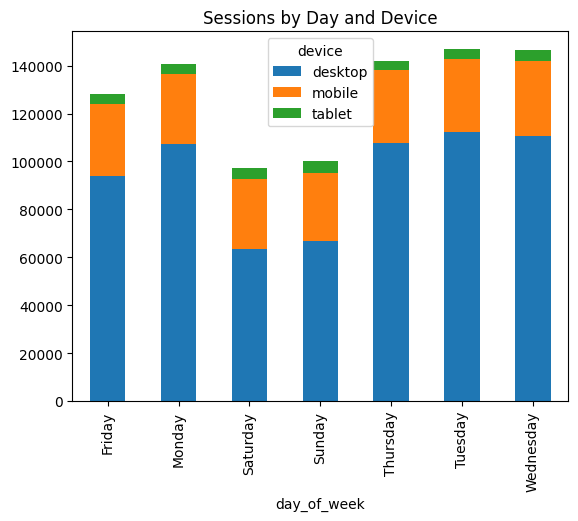

In [86]:
df.groupby(['day_of_week', 'device']).size().unstack().plot(kind='bar', stacked=True)
plt.title("Sessions by Day and Device")
plt.show()

### Monthly Sessions - Key Insights

- User activity increases steadily from August to November, reaching a peak in November.
- This peak is likely driven by seasonal events such as Black Friday.
- A significant decline follows in December and continues into early months of the next year.
- From March onwards, sessions stabilize with minor fluctuations.
- The drop observed in August is likely due to incomplete data.

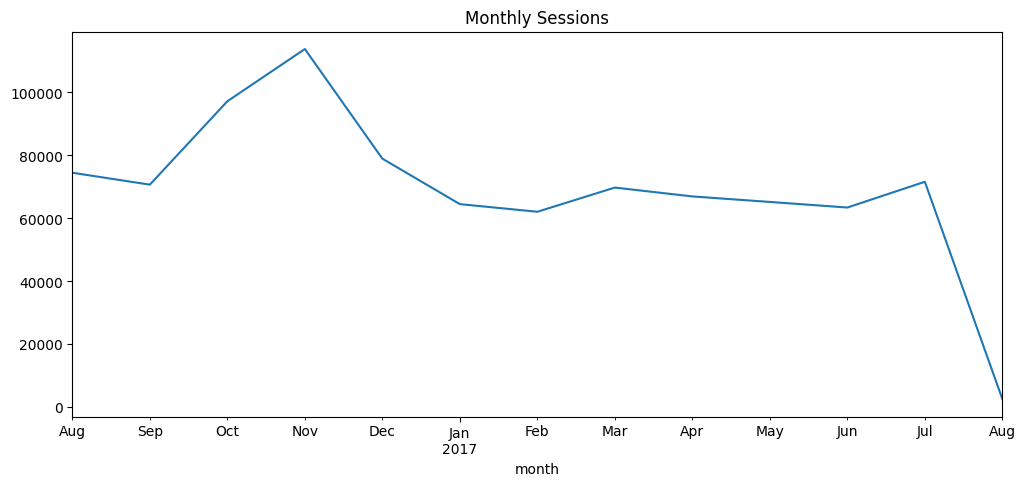

In [87]:
df['month'] = df['date'].dt.to_period('M')

df.groupby('month').size().plot(figsize=(12,5))
plt.title("Monthly Sessions")
plt.show()

### Revenue Analysis

### Revenue Distribution - Key Insights

- The majority of sessions (over 75%) generate no revenue.
- Revenue distribution is highly skewed, with a small number of sessions generating very high values.
- This indicates that conversion is rare and should be analyzed separately from raw revenue.
- Therefore, conversion rate is a more meaningful metric than average revenue.

In [88]:
df['revenue'].describe()

count    901288.000000
mean          1.974045
std          83.262875
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       47082.060000
Name: revenue, dtype: float64

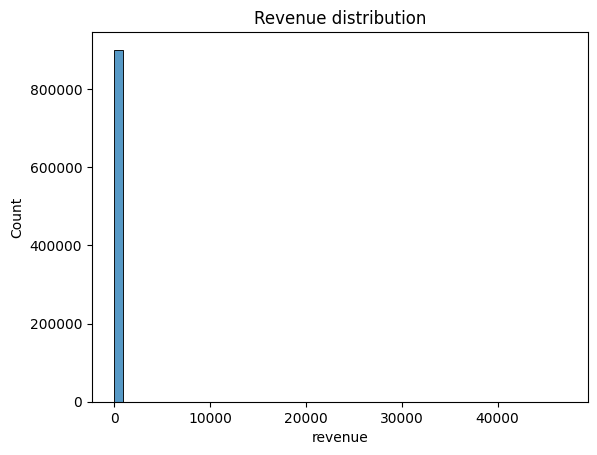

In [89]:
sns.histplot(df['revenue'], bins=50)
plt.title("Revenue distribution")
plt.show()

### Conversion Rate Analysis

### Conversion Rate by Day of Week - Key Insights

- Conversion rates are significantly lower during weekends, with Saturday showing the lowest performance.
- Weekend conversion rates are nearly half of weekday levels.
- This indicates that reduced performance on weekends is driven not only by lower traffic but also by lower purchase intent.
- Conversion peaks on Monday and Friday, suggesting behavioral patterns linked to user routines.

In [90]:
df['converted'] = df['revenue'] > 0

In [91]:
(df.groupby('day_of_week')['converted']
   .mean()
   .mul(100)
   .round(2)
   .astype(str) + '%')

day_of_week
Friday       1.46%
Monday       1.46%
Saturday      0.8%
Sunday       0.94%
Thursday     1.34%
Tuesday      1.37%
Wednesday    1.32%
Name: converted, dtype: object

### Pageviews vs Conversion - Key Insights

- Users who convert view significantly more pages (~28) compared to non-converting users (~3.5).
- This suggests that engagement is a strong indicator of purchase intent.
- Users who explore more of the website are far more likely to complete a transaction.
- Increasing user engagement could be a key strategy to improve conversion rates.

In [92]:
df.groupby('converted')['pageviews'].mean()

converted
False     3.537633
True     28.400070
Name: pageviews, dtype: float64

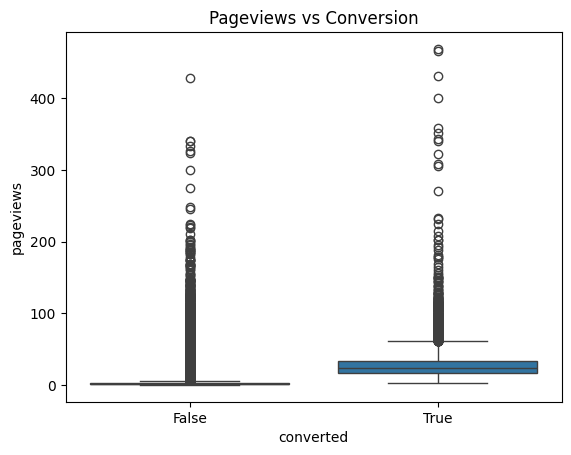

In [93]:
sns.boxplot(x='converted', y='pageviews', data=df)
plt.title("Pageviews vs Conversion")
plt.show()

### Conversion Rate by Pageview Buckets - Key Insights

- Conversion probability increases significantly with the number of pageviews.
- Users with fewer than 10 pageviews have a very low likelihood of converting.
- A critical threshold is observed around 10 pageviews, after which conversion rates increase sharply.
- Users with more than 20 pageviews show strong purchase intent, with conversion rates exceeding 25%.
- This suggests that increasing user engagement is key to improving conversion performance.

In [94]:
df['pageview_bucket'] = pd.cut(df['pageviews'], bins=[0,1,5,10,20,50,100,500])

df.groupby('pageview_bucket')['converted'].mean()

C:\Users\gabii\AppData\Local\Temp\ipykernel_33008\2088611296.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('pageview_bucket')['converted'].mean()


pageview_bucket
(0, 1]        0.000000
(1, 5]        0.000068
(5, 10]       0.006124
(10, 20]      0.089851
(20, 50]      0.255319
(50, 100]     0.361956
(100, 500]    0.402439
Name: converted, dtype: float64

### Converted and Transactions Analysis

### Transactions Distribution - Key Insights

- The vast majority of sessions (over 98%) have zero transactions.
- Among converting sessions, most users perform exactly one transaction.
- Multiple transactions within a single session are rare and represent edge cases.
- This suggests that conversion is typically a single-purchase event.
- Therefore, the binary conversion metric is sufficient to capture most purchasing behavior.

In [95]:
df['transactions'].value_counts().head(10)

transactions
0.0     889743
1.0      11192
2.0        284
3.0         31
4.0         13
5.0          9
6.0          5
8.0          3
7.0          3
10.0         1
Name: count, dtype: int64

In [96]:
df.groupby('converted')['transactions'].describe()

,count,mean,std,min,25%,50%,75%,max
converted,,,,,,,,
False,889780.0,0.000046,0.007862,0.0,0.0,0.0,0.0,4.0
True,11508.0,1.048575,0.455345,1.0,1.0,1.0,1.0,25.0


In [97]:
df[df['converted'] == True]['transactions'].value_counts()

transactions
1.0     11157
2.0       283
3.0        31
4.0        12
5.0         9
6.0         5
8.0         3
7.0         3
10.0        1
21.0        1
25.0        1
12.0        1
15.0        1
Name: count, dtype: int64

### High Engagement Users (Multiple Transactions) - Key Insights

- Users with multiple transactions exhibit extremely high engagement levels.
- These users have a median of ~45 pageviews and an average of ~63 pageviews.
- This is significantly higher than both non-converting users and single-transaction users.
- This suggests that deeper exploration of the website is strongly associated with higher purchase intensity.

In [98]:
df[df['transactions'] > 1]['pageviews'].describe()

count    353.000000
mean      63.178470
std       62.239588
min       16.000000
25%       31.000000
50%       45.000000
75%       71.000000
max      469.000000
Name: pageviews, dtype: float64

### New vs Returning Users - Key Insights

- Returning users have a significantly higher conversion rate (~3.5%) compared to new users (~0.6%).
- This represents nearly a 5x increase in conversion likelihood.
- This suggests that users typically require multiple interactions before making a purchase.
- Improving user retention and return visits could significantly increase overall conversion performance.

In [99]:
df.columns

Index(['fullVisitorId', 'visitId', 'date', 'country', 'device',
       'channelGrouping', 'day_of_week', 'month', 'is_returning',
       'pageview_bucket', 'revenue', 'transactions', 'visits', 'pageviews',
       'converted'],
      dtype='object')

In [100]:
df['is_returning'] = df['visitId'] > 1

df.groupby('is_returning')['converted'].mean()

is_returning
True    0.012768
Name: converted, dtype: float64

### Engagement by Visit Number - Key Insights

- User engagement increases with the number of visits, as shown by higher average pageviews.
- First-time visitors show low engagement, while returning users explore more content.
- This suggests a learning or familiarity effect, where users become more comfortable navigating the platform over time.
- Increased engagement in later visits is likely a key driver of higher conversion rates.

In [101]:
df.groupby('visitId')['pageviews'].mean()

visitId
1470034812    1.0
1470035066    1.0
1470035081    5.0
1470035161    7.0
1470035170    1.0
             ... 
1501657161    1.0
1501657166    2.0
1501657186    1.0
1501657190    1.0
1501657193    1.0
Name: pageviews, Length: 884878, dtype: float64

### Conversion by Visit Number - Key Insights

- Conversion rates increase significantly with the number of user visits.
- First-time visitors have a very low conversion rate (~0.6%), while returning users show progressively higher conversion rates.
- The largest increase occurs between the first and second visit.
- After several visits, conversion rates begin to stabilize.
- This suggests a typical user journey from exploration to consideration to purchase.

In [102]:
df.groupby('visitId')['converted'].mean()

visitId
1470034812    0.0
1470035066    0.0
1470035081    0.0
1470035161    0.0
1470035170    0.0
             ... 
1501657161    0.0
1501657166    0.0
1501657186    0.0
1501657190    0.0
1501657193    0.0
Name: converted, Length: 884878, dtype: float64

While it may seem intuitive that higher engagement leads to higher conversion, this analysis demonstrates that the relationship is not linear and depends on multiple factors such as user experience, visit frequency, and external conditions.

By quantifying these effects, the study provides a deeper understanding of user behavior beyond common assumptions.

In [103]:
df.dtypes

fullVisitorId              object
visitId                     int64
date               datetime64[ns]
country                    object
device                     object
channelGrouping            object
day_of_week                object
month                   period[M]
is_returning                 bool
pageview_bucket          category
revenue                   float64
transactions              float64
visits                      int64
pageviews                   int64
converted                    bool
dtype: object

In [104]:
df = df.groupby(['fullVisitorId', 'visitId']).agg({
    # dimensions
    'date': 'first',
    'country': 'first',
    'device': 'first',
    'channelGrouping': 'first',
    'day_of_week': 'first',
    'month': 'first',
    'is_returning': 'first',
    'pageview_bucket': 'first',

    # metrics
    'revenue': 'max',
    'transactions': 'max',
    'visits': 'max',
    'pageviews': 'sum',

    # target
    'converted': 'max'
}).reset_index()

In [105]:
df.head()

,fullVisitorId,visitId,date,country,device,channelGrouping,day_of_week,month,is_returning,pageview_bucket,revenue,transactions,visits,pageviews,converted
0,000005103959234087,1471817208,2016-08-21,United States,mobile,Organic Search,Sunday,2016-08,True,"(5, 10]",0.0,0.0,1,8,False
1,0000085059828173212,1500505105,2017-07-19,United States,mobile,Direct,Wednesday,2017-07,True,"(0, 1]",0.0,0.0,1,1,False
2,0000176652019531658,1484597865,2017-01-16,Bangladesh,desktop,Social,Monday,2017-01,True,"(0, 1]",0.0,0.0,1,1,False
3,000033471059618621,1480289088,2016-11-27,Turkey,desktop,Social,Sunday,2016-11,True,"(0, 1]",0.0,0.0,1,1,False
4,0000388388833742701,1480256233,2016-11-27,Thailand,desktop,Social,Sunday,2016-11,True,"(1, 5]",0.0,0.0,1,2,False


In [106]:
df.shape

(901288, 15)

In [107]:
df.to_csv("../data/processed/sessions_clean.csv", index=False)